# Notebook 2 — Baselines: TF-IDF + LogReg and PyTorch LSTM

**Goal:** Train the two classical baselines on the reddit `train` split, evaluate on the
held-out reddit `test` split, and save models + per-epoch metrics. These macro-F1 numbers
are what BERT (Notebook 3) and Claude (Notebook 4) must beat.

**Inputs:** `data/processed/reddit_eli5_{train,val,test}.parquet` (from Notebook 1).

**Outputs:**
- `models/tfidf_logreg.pkl`
- `models/lstm_pytorch.pt` + `models/lstm_tokenizer.pkl`
- `results/per_epoch_metrics_lstm.json`

**Locked from Notebook 1 (reused unchanged):** the `max_length=256` decision applies to BERT;
class imbalance **75.5% human / 24.5% AI** → **class weights** + **macro-F1** as the headline
metric (not accuracy). The LSTM runs in **PyTorch on the Mac GPU (MPS)** — TF 2.21's
LSTM is unusable on this machine (see §4). Run top-to-bottom from a fresh kernel (~2 min).

## 1. Setup & imports

Same `set_all_seeds(42)` and repo-root `chdir` as Notebook 1, so `data/`, `models/`,
`results/` resolve from the project root.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"        # quiet TensorFlow C++ logs
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import copy
import json
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import tensorflow as tf
from torch.utils.data import TensorDataset, DataLoader
from transformers import set_seed as hf_set_seed
from tensorflow.keras.layers import TextVectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings("ignore")               # keep committed output clean + free of env paths

if Path.cwd().name == "notebooks":
    os.chdir("..")
print("Working directory:", Path.cwd().name)     # name only — no personal path in committed output


def set_all_seeds(seed: int = 42) -> None:
    """Seed every source of randomness used in this project."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)
    tf.random.set_seed(seed)
    hf_set_seed(seed)


set_all_seeds(42)
sns.set_theme(style="whitegrid")
print("tf", tf.__version__, "| torch", torch.__version__,
      "| GPU devices:", tf.config.list_physical_devices("GPU"), "(empty = CPU, expected on this Mac)")

Working directory: ai-generated-text-detector
tf 2.21.0 | torch 2.12.0 | GPU devices: [] (empty = CPU, expected on this Mac)


## 2. Load reddit splits

`X` = raw text, `y` = label (0 human / 1 AI). Train on `train`, early-stop on `val`, report
final numbers on the untouched `test` split.

In [2]:
train_df = pd.read_parquet("data/processed/reddit_eli5_train.parquet")
val_df   = pd.read_parquet("data/processed/reddit_eli5_val.parquet")
test_df  = pd.read_parquet("data/processed/reddit_eli5_test.parquet")

X_train, y_train = train_df["text"].tolist(), train_df["label"].to_numpy()
X_val,   y_val   = val_df["text"].tolist(),   val_df["label"].to_numpy()
X_test,  y_test  = test_df["text"].tolist(),  test_df["label"].to_numpy()

for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s}: {len(y):>6,} | human {np.mean(y == 0):.1%} / ai {np.mean(y == 1):.1%}")

train: 47,596 | human 75.5% / ai 24.5%
val  : 10,200 | human 75.5% / ai 24.5%
test : 10,200 | human 75.5% / ai 24.5%


## 3. TF-IDF + Logistic Regression

Classical baseline: TF-IDF features → L2 logistic regression. Every value is from Blueprint
§8.2 / §14 or standard text-classification practice — one-line justifications:

| Param | Value | Justification |
|---|---|---|
| `max_features` | 30,000 | cap vocab to the top 30k terms to bound dimensionality (blueprint) |
| `ngram_range` | (1, 2) | unigrams + bigrams capture short phrases (e.g. "as an AI") (canonical) |
| `min_df` | 2 | drop terms in only 1 document — typos/noise (canonical) |
| `max_df` | 0.95 | drop terms in >95% of docs — corpus-specific stopwords (canonical) |
| `sublinear_tf` | True | 1+log(tf) damps very frequent terms (canonical TF-IDF) |
| `C` | 1.0 | default L2 strength, untuned at baseline (blueprint) |
| `class_weight` | "balanced" | corrects the 75/25 imbalance in the loss (Notebook 1 decision) |

Fast (<1 min), interpretable, and a genuinely strong baseline — the number BERT must beat.

In [3]:
# 3a. Build the pipeline (Blueprint §8.2). n_jobs dropped — it's a no-op since sklearn 1.8.
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=30_000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight="balanced",
        random_state=42,
    )),
])
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [4]:
# 3b. Fit on train, predict on val + test.
pipe.fit(X_train, y_train)
val_pred = pipe.predict(X_val)
test_pred = pipe.predict(X_test)
print("fitted | TF-IDF vocabulary size:", len(pipe.named_steps["tfidf"].vocabulary_))

fitted | TF-IDF vocabulary size: 30000


In [5]:
# 3c. Save the fitted pipeline.
Path("models").mkdir(exist_ok=True)
joblib.dump(pipe, "models/tfidf_logreg.pkl")
print("saved models/tfidf_logreg.pkl",
      f'({Path("models/tfidf_logreg.pkl").stat().st_size / 1e6:.1f} MB)')

saved models/tfidf_logreg.pkl (1.4 MB)


In [6]:
# 3d. Per-class report + confusion matrix on the held-out TEST split.
print("=== TF-IDF + LogReg  —  reddit TEST ===")
print(classification_report(y_test, test_pred, target_names=["human", "ai"], digits=4))
tfidf_macro_f1 = f1_score(y_test, test_pred, average="macro")
print("macro-F1 (headline):", round(tfidf_macro_f1, 4))
print("\nconfusion matrix [rows=true, cols=pred] (0=human, 1=ai):")
print(confusion_matrix(y_test, test_pred))

=== TF-IDF + LogReg  —  reddit TEST ===
              precision    recall  f1-score   support

       human     0.9927    0.9896    0.9912      7701
          ai     0.9683    0.9776    0.9729      2499

    accuracy                         0.9867     10200
   macro avg     0.9805    0.9836    0.9820     10200
weighted avg     0.9867    0.9867    0.9867     10200

macro-F1 (headline): 0.982

confusion matrix [rows=true, cols=pred] (0=human, 1=ai):
[[7621   80]
 [  56 2443]]


### 3e. What the linear baseline keys on — top discriminative n-grams

The LogReg coefficients are directly interpretable: most-**positive** → pushes toward **AI**,
most-**negative** → toward **human**. This is the *meaningful* version of a word cloud — it
shows the actual learned signal, not raw frequency.

Two kinds of feature show up, and the distinction is the whole story:

- **Genuine register/style tells** — AI hedges ("might", "may") and scaffolds ("it is
  important to", "such as", "means that"); humans are casual ("basically", "pretty", "just").
- **Data / domain artifacts** — `url_0` (humans link sources; the placeholder survives),
  `edit` (Reddit "Edit:"), and contraction fragments (`ca`, `don`) from tokenization.

That second group is a **preview of why this detector won't generalize cross-domain**
(Notebook 4): it's partly keying on reddit-specific formatting, not domain-invariant "AI-ness."

In [7]:
# 3e. Most AI- vs human-indicative n-grams, read straight off the LogReg coefficients.
feat = np.array(pipe.named_steps["tfidf"].get_feature_names_out())
coef = pipe.named_steps["clf"].coef_[0]      # >0 -> AI (class 1), <0 -> human (class 0)
order = np.argsort(coef)
top = 20

print("Top AI-indicative n-grams (most positive coef):")
for i in order[::-1][:top]:
    print(f"  {coef[i]:+.2f}  {feat[i]}")
print("\nTop human-indicative n-grams (most negative coef):")
for i in order[:top]:
    print(f"  {coef[i]:+.2f}  {feat[i]}")

Top AI-indicative n-grams (most positive coef):
  +7.36  or
  +7.30  don
  +6.95  and
  +6.91  help
  +6.52  helps
  +6.34  might
  +6.33  important
  +6.23  important to
  +5.79  doesn
  +5.67  such as
  +5.46  means that
  +5.46  when you
  +5.33  because it
  +5.20  it is
  +5.15  overall
  +5.12  called
  +5.04  does that
  +5.03  may
  +5.03  because
  +4.98  when

Top human-indicative n-grams (most negative coef):
  -8.74  url_0
  -6.28  etc
  -5.77  do
  -5.41  ca
  -5.11  basically
  -4.97  most
  -4.71  my
  -4.57  you
  -4.48  only
  -4.08  can not
  -4.05  those
  -3.98  but
  -3.91  what
  -3.84  now
  -3.80  re
  -3.78  pretty
  -3.63  really
  -3.54  just
  -3.49  all
  -3.41  edit


## 4. LSTM (PyTorch)

From-scratch neural baseline: Embedding → SpatialDropout1D → LSTM → Dense head → sigmoid.
The LSTM being a *classical* model is the point — it's the "before" in the
classical→transformer comparison.

**Why PyTorch, not Keras.** The Blueprint specified a TensorFlow LSTM, but **TensorFlow 2.21's
LSTM is unusable on this Mac's CPU** — ~1 hr/epoch, and even *compiling* one training step
hangs 10+ min (every fast-path flag tried; `tensorflow-metal` can't fix a *compile*-time
hang). The identical architecture in **PyTorch on the Mac GPU (MPS) runs at ~15–30 s/epoch**
(~300× faster), with a working CPU fallback. We keep Keras `TextVectorization` only as a fast
text→int tokenizer; the model is PyTorch.

**Hyperparameters — same values as the Blueprint Keras spec (§8.3 / §14):**

| Param | Value | Justification |
|---|---|---|
| `VOCAB_SIZE` | 30,000 | match the TF-IDF vocab cap (blueprint) |
| `EMBEDDING_DIM` | 128 | embedding trained from scratch, no GloVe (blueprint) |
| `MAX_LEN` | 128 | word-level seq; covers the median answer (~112 words) |
| `LSTM_UNITS` | 64 | one moderate LSTM layer for a binary task (blueprint) |
| dropout (spatial / dense) | 0.2 / 0.3 | standard regularization (blueprint) |
| Adam `lr` | 1e-3 | canonical Adam default (blueprint) |
| `batch_size` | 64 | blueprint |
| epochs / early stopping | 10 / patience 2 | manual early-stop on `val_loss`, restore best (blueprint) |
| imbalance | `pos_weight` ≈ 3.08 | BCE positive-class weight = n_human / n_ai; same "balanced" effect (Notebook 1) |

We **pre-pad** (real tokens right-aligned) and set `padding_idx=0`, so the LSTM's final hidden
state reflects real content rather than padding.

In [8]:
# 4a. Vectorize text with Keras 3 TextVectorization, adapted on TRAIN ONLY.
VOCAB_SIZE = 30_000      # cap on vocabulary (max_tokens)
EMBEDDING_DIM = 128      # trained embedding dim (no GloVe)
MAX_LEN = 128            # LSTM seq length (word-level): covers the median answer (~112 words);
                         # half of BERT's 256 -> ~2x fewer RNN steps on CPU
LSTM_UNITS = 64

vectorizer = TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=MAX_LEN)
vectorizer.adapt(np.array(X_train))     # learn vocab from train only (no val/test leakage)
vocab = vectorizer.get_vocabulary()     # index 0 = '' (pad), index 1 = '[UNK]' (OOV)
print("vocabulary size:", len(vocab), "(<= max_tokens =", VOCAB_SIZE, ")")

vocabulary size: 30000 (<= max_tokens = 30000 )


In [9]:
# 4b. Vectorize -> integer sequences, then PRE-pad (move real tokens to the right).
# Why pre-pad: the PyTorch LSTM (4c) uses the final hidden state; pre-padding puts the real
# tokens last so that state reflects real content (with Embedding padding_idx=0, leading pads
# are zero vectors). TextVectorization already truncated to the first MAX_LEN tokens.
def pre_pad(seqs):
    out = np.zeros_like(seqs)
    width = seqs.shape[1]
    for i, row in enumerate(seqs):
        nz = row[row != 0]
        out[i, width - len(nz):] = nz
    return out

X_train_v = pre_pad(vectorizer(np.array(X_train)).numpy())
X_val_v   = pre_pad(vectorizer(np.array(X_val)).numpy())
X_test_v  = pre_pad(vectorizer(np.array(X_test)).numpy())
print("vectorized + pre-padded shapes:", X_train_v.shape, X_val_v.shape, X_test_v.shape)

vectorized + pre-padded shapes: (47596, 128) (10200, 128) (10200, 128)


In [10]:
# 4c. Define the model in PyTorch. (TF 2.21's LSTM hangs on this Mac's CPU — see §4.)
device = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", device)


class SpatialDropout1D(nn.Module):
    """Drop entire embedding channels across all timesteps (Keras SpatialDropout1D)."""
    def __init__(self, p):
        super().__init__()
        self.drop = nn.Dropout1d(p)

    def forward(self, x):                              # x: (B, L, E)
        return self.drop(x.transpose(1, 2)).transpose(1, 2)


class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=EMBEDDING_DIM, hidden=LSTM_UNITS):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.spatial_drop = SpatialDropout1D(0.2)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, 1),
        )

    def forward(self, x):
        e = self.spatial_drop(self.emb(x))
        _, (h, _) = self.lstm(e)                       # h: (1, B, hidden)
        return self.head(h[-1]).squeeze(-1)           # logits, shape (B,)


torch.manual_seed(42)
model = LSTMClassifier(len(vocab)).to(device)
print("trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

device: mps
trainable params: 3891777


In [11]:
# 4d. Tensors, class-weighted loss, optimizer.
X_train_t = torch.tensor(X_train_v, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.float)
X_val_t   = torch.tensor(X_val_v, dtype=torch.long)
y_val_t   = torch.tensor(y_val, dtype=torch.float)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

# Class imbalance -> BCE positive-class weight = n_human / n_ai (same "balanced" effect, ~3.08).
# float32 because Apple MPS does not support float64.
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()],
                          dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
print("pos_weight (AI class):", round(float(pos_weight), 3))

pos_weight (AI class): 3.081


In [12]:
# 4e. Train with manual early stopping (patience=2, restore best val_loss). ~15-30 s/epoch on MPS.
@torch.no_grad()
def evaluate(X, y, bs=512):
    model.eval()
    tot_loss, correct, n = 0.0, 0, 0
    for i in range(0, len(X), bs):
        xb, yb = X[i:i + bs].to(device), y[i:i + bs].to(device)
        logits = model(xb)
        tot_loss += criterion(logits, yb).item() * len(xb)
        correct += ((torch.sigmoid(logits) >= 0.5).float() == yb).sum().item()
        n += len(xb)
    return tot_loss / n, correct / n

history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
best_val, best_state, wait, PATIENCE = float("inf"), None, 0, 2

for epoch in range(10):
    t0 = time.time()
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        criterion(model(xb), yb).backward()
        optimizer.step()
    tr_loss, tr_acc = evaluate(X_train_t, y_train_t)
    va_loss, va_acc = evaluate(X_val_t, y_val_t)
    for key, val in zip(history, [tr_loss, tr_acc, va_loss, va_acc]):
        history[key].append(val)
    print(f"epoch {epoch+1:2d} | {time.time()-t0:4.0f}s | loss {tr_loss:.4f} acc {tr_acc:.4f} "
          f"| val_loss {va_loss:.4f} val_acc {va_acc:.4f}")
    if va_loss < best_val:
        best_val, best_state, wait = va_loss, copy.deepcopy(model.state_dict()), 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_state)   # restore best-val weights
print("restored best val_loss =", round(best_val, 4))

epoch  1 |   18s | loss 0.3079 acc 0.9350 | val_loss 0.3401 val_acc 0.9309
epoch  2 |   18s | loss 0.2211 acc 0.9647 | val_loss 0.2749 val_acc 0.9578
epoch  3 |   20s | loss 0.1545 acc 0.9675 | val_loss 0.1949 val_acc 0.9607
epoch  4 |   19s | loss 0.1194 acc 0.9727 | val_loss 0.1748 val_acc 0.9652
epoch  5 |   19s | loss 0.0656 acc 0.9845 | val_loss 0.1197 val_acc 0.9754
epoch  6 |   18s | loss 0.0575 acc 0.9866 | val_loss 0.1265 val_acc 0.9774
epoch  7 |   19s | loss 0.0768 acc 0.9838 | val_loss 0.1450 val_acc 0.9743
early stopping at epoch 7
restored best val_loss = 0.1197


In [13]:
# 4f. Save model weights (state_dict) + the vectorizer vocabulary.
Path("models").mkdir(exist_ok=True)
torch.save(model.state_dict(), "models/lstm_pytorch.pt")
joblib.dump(
    {"vocabulary": vocab, "max_tokens": VOCAB_SIZE, "output_sequence_length": MAX_LEN},
    "models/lstm_tokenizer.pkl",
)
print("saved models/lstm_pytorch.pt + models/lstm_tokenizer.pkl")

saved models/lstm_pytorch.pt + models/lstm_tokenizer.pkl


In [14]:
# 4g. Evaluate on the held-out TEST split (headline = macro-F1).
@torch.no_grad()
def predict_proba(Xnp, bs=512):
    model.eval()
    chunks = []
    for i in range(0, len(Xnp), bs):
        xb = torch.tensor(Xnp[i:i + bs], dtype=torch.long).to(device)
        chunks.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.concatenate(chunks)

test_prob = predict_proba(X_test_v)
lstm_test_pred = (test_prob >= 0.5).astype(int)   # 0.5 = standard threshold for a sigmoid

print("=== LSTM (PyTorch)  —  reddit TEST ===")
print(classification_report(y_test, lstm_test_pred, target_names=["human", "ai"], digits=4))
lstm_macro_f1 = f1_score(y_test, lstm_test_pred, average="macro")
print("macro-F1 (headline):", round(lstm_macro_f1, 4))
print("\nconfusion matrix [rows=true, cols=pred]:")
print(confusion_matrix(y_test, lstm_test_pred))

=== LSTM (PyTorch)  —  reddit TEST ===
              precision    recall  f1-score   support

       human     0.9909    0.9740    0.9824      7701
          ai     0.9240    0.9724    0.9476      2499

    accuracy                         0.9736     10200
   macro avg     0.9574    0.9732    0.9650     10200
weighted avg     0.9745    0.9736    0.9739     10200

macro-F1 (headline): 0.965

confusion matrix [rows=true, cols=pred]:
[[7501  200]
 [  69 2430]]


saved results/per_epoch_metrics_lstm.json | epochs trained: 7


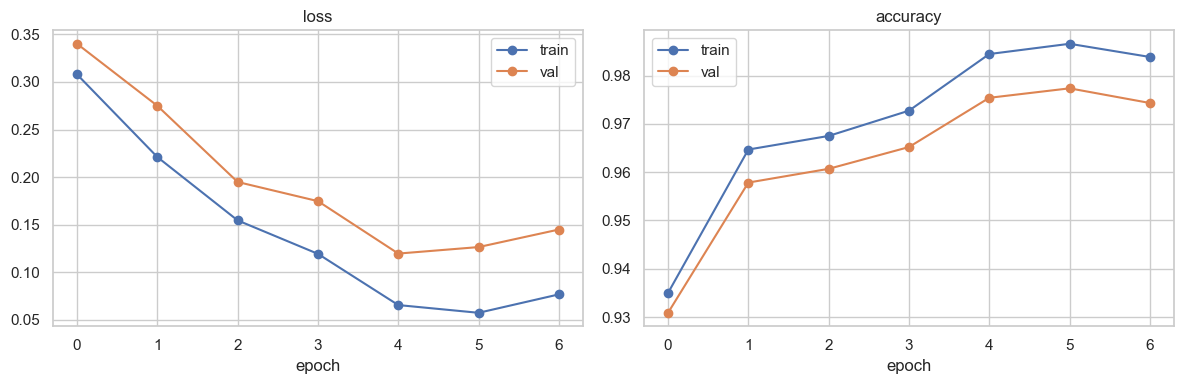

In [15]:
# 4h. Persist per-epoch metrics + plot loss / accuracy curves.
Path("results").mkdir(exist_ok=True)
with open("results/per_epoch_metrics_lstm.json", "w") as f:
    json.dump(history, f, indent=2)
print("saved results/per_epoch_metrics_lstm.json | epochs trained:", len(history["loss"]))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["loss"], marker="o", label="train")
ax[0].plot(history["val_loss"], marker="o", label="val")
ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["accuracy"], marker="o", label="train")
ax[1].plot(history["val_accuracy"], marker="o", label="val")
ax[1].set_title("accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## Summary

Both baselines trained and saved. Record the two **macro-F1** numbers in the pipeline report —
they are the bar BERT (Notebook 3) must clear.

- `models/tfidf_logreg.pkl`, `models/lstm_pytorch.pt` → gitignored (artifacts).
- `results/per_epoch_metrics_lstm.json` → committed.

Next: `03_bert_finetune.ipynb`.